# Notebook for dhcp and others dataset
Pre-processing steps and checks

In [1]:
import ants
import os, shutil
import subprocess
import nibabel as nib
import pandas as pd 
import utils as ut

from glob import glob
from natsort import natsorted, natsort_keygen

In [2]:
sourcepath = '/Users/arnaud/Desktop/sourcedata_orig'

In [3]:
subjects = glob(sourcepath+'/sub*/')
scans = glob(sourcepath+'/sub*/ses*/anat/*.nii.gz')

print(f"# subjects : {len(subjects)}, # scans {len(scans)}")

# subjects : 505, # scans 2100


I already "skull-stripped" the scans, so that's why we have x2 more than expected

In [4]:
scans_full = [i for i in scans if "skull" not in i] # source scans with brain + skull
t1_scans = [i for i in scans_full if "T1" in i]
t2_scans = [i for i in scans_full if "T2" in i]

print(f"# T1 scans :{len(t1_scans)}, # T2 scans :{len(t2_scans)}")

# T1 scans :492, # T2 scans :558


Now we check the data [tuto](https://nipy.org/nibabel/nifti_images.html)

In [5]:
im = nib.load(t1_scans[0])
print(im.header) # pixdim of 0.5mm^3 is a bit of a problem for the next steps

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 290 290 203   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float64
bitpix          : 64
slice_start     : 0
pixdim          : [-1.   0.5  0.5  0.5  1.   0.   0.   0. ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'5.0.11'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 67.539246
qoffset_y       : -63.214935
qoffset_z       : -32.774918
srow_x     

## Step 1 : registration 
[TO READ](https://3dqlab.stanford.edu/image-registration/)  + [AND THIS ](https://github.com/ANTsX/ANTs/wiki/Tips-for-improving-registration-results)  
In MRI research, registration is usually necessary to align the image with some normalized resolution (spacing), position (direction), contrast and bias field suppression.  
Here we perform it with ants-py.  

UPDATE : I found some published work on the creation of atlases from the same dataset I'm using, so I'll use this for registration. [link](https://gin.g-node.org/BioMedIA/dhcp-volumetric-atlas-groupwise).  
(Large git)

IMPORTANT : in neonatal dataset the age (in WEEKS) is very important, thus there is a template for each week.  
We have the age of the scans from the source data.  

In [6]:
csvpath = '/Users/arnaud/Desktop/sourcedata_orig/participants.tsv'
ds_info = pd.read_csv(csvpath, sep ='\t')
ds_info.head()

,participant_id,gender,birth_age,birth_weight,singleton
0,CC00549XX22,Female,42.000000,3.685,Single
1,CC00576XX16,Male,28.857143,0.850,Single
2,CC00202XX04,Male,38.571429,2.630,Single
3,CC00720XX11,Female,40.428571,3.950,Single
4,CC00388XX18,Female,34.428571,2.800,Single


Sort both scans and table

In [7]:
sorted_ds = ds_info.sort_values(
    by="participant_id",
    key=natsort_keygen()
)
sorted_ds.head()

,participant_id,gender,birth_age,birth_weight,singleton
174,CC00058XX09,Male,40.285714,4.135,Single
132,CC00060XX03,Female,40.142857,2.845,Single
479,CC00062XX05,Female,41.285714,4.050,Single
33,CC00063AN06,Female,35.142857,1.950,Multiple
477,CC00065XX08,Male,40.428571,3.400,Single


In [8]:
scans_sorted = natsorted(scans_full)
scans_sorted[:5]

['/Users/arnaud/Desktop/sourcedata_orig/sub-CC00058XX09/ses-11300/anat/sub-CC00058XX09_ses-11300_T2w.nii.gz',
 '/Users/arnaud/Desktop/sourcedata_orig/sub-CC00060XX03/ses-12501/anat/sub-CC00060XX03_ses-12501_T1w.nii.gz',
 '/Users/arnaud/Desktop/sourcedata_orig/sub-CC00060XX03/ses-12501/anat/sub-CC00060XX03_ses-12501_T2w.nii.gz',
 '/Users/arnaud/Desktop/sourcedata_orig/sub-CC00062XX05/ses-13801/anat/sub-CC00062XX05_ses-13801_T1w.nii.gz',
 '/Users/arnaud/Desktop/sourcedata_orig/sub-CC00062XX05/ses-13801/anat/sub-CC00062XX05_ses-13801_T2w.nii.gz']

Example test:  
first subject is gest. age 40, T2 

In [9]:
template_dhcp_42_t2 = ants.image_read('/Users/arnaud/Documents/GitHub/dhcp-volumetric-atlas-groupwise/mean/ga_42/template_t2.nii.gz')
im0_t2 = ants.image_read(scans_sorted[0])
im0_t2, template_dhcp_42_t2

(ANTsImage (RPI)
 	 Pixel Type : float (float32)
 	 Components : 1
 	 Dimensions : (290, 290, 203)
 	 Spacing    : (0.5, 0.5, 0.5)
 	 Origin     : (-71.7126, 57.3517, -42.927)
 	 Direction  : [ 1.  0.  0.  0. -1.  0.  0.  0.  1.],
 ANTsImage (RPI)
 	 Pixel Type : float (float32)
 	 Components : 1
 	 Dimensions : (202, 274, 217)
 	 Spacing    : (0.5, 0.5, 0.5)
 	 Origin     : (-51.9688, 84.5313, -39.0078)
 	 Direction  : [ 1.  0.  0.  0. -1.  0.  0.  0.  1.])

In [10]:
# Perform registration with SyN algorithm
transformed_image = ants.registration(fixed=template_dhcp_42_t2, moving=im0_t2, type_of_transform='SyN') # idk what SyN does

The transformed image has the resolution of the template

In [11]:
# print(f"Saved registered image to {os.path.abspath(output_path)}. \n")
ants.image_write(transformed_image['warpedmovout'], "./sample/registered_0.nii.gz")
transformed_image
nib.load("./sample/registered_0.nii.gz").get_fdata().shape

(202, 274, 217)

Some 2D visualization

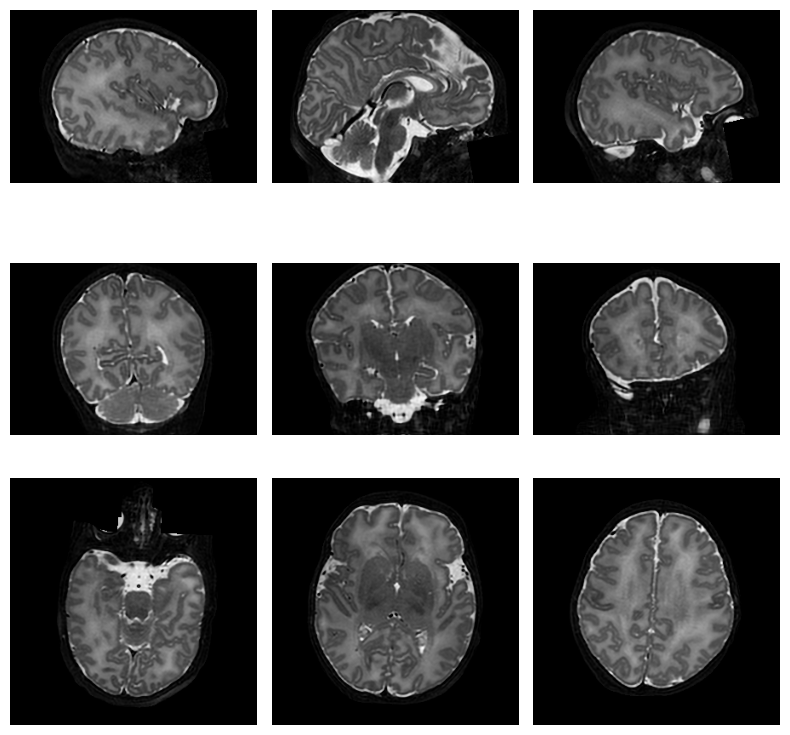

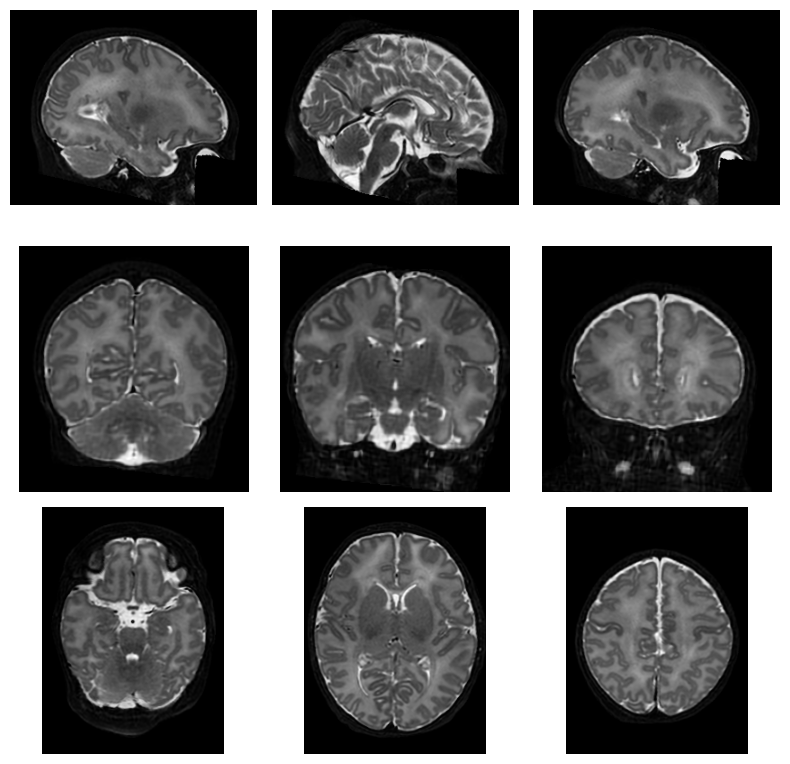

In [12]:
plot = ut.visualize_nifti_depth(scans_sorted[0])
plot = ut.visualize_nifti_depth("./sample/registered_0.nii.gz")

In [13]:
# I have done ALL the previous registration with these, which is pretty bad 
# template_file1 = ants.image_read("./registre/Akiyama_6Month_1_5T.nii.gz")
# template_file3 = ants.image_read("./registre/Akiyama_6Month_3T.nii.gz")

## Step 2 : skull-strip  
After the registration, we can perform skull-striping.  
This is not necessary for the brain segmentation tool, but it can be usefull to keep the skull vs brainmatter.  
**Do we need it before or after registration ?** -> depends what we do with the brain vs skull, shouldnt change too much

Skullstrip takes *input*, *output* and *mask* arguments.  
Mask is the binary brain mask.  
Docker version, so have it ready too. 

In [ ]:
# Check and start Docker if necessary
if not ut.is_docker_running():
    print("Docker is not running. Starting it now...")
    ut.start_docker()
else:
    print("Docker is running.")

In [14]:
# Using sample 0 again for test :
inp = './sample/registered_0.nii.gz'
out = './sample/brain_0.nii.gz'
mask = './sample/mask_0.nii.gz'
strip_process = subprocess.run([f'./synthstrip.py -i {inp} -o {out} -m {mask} --no-csf'], shell = True) # no csf : exclude csf 

Configuring model on the CPU
Running SynthStrip model version 1
Excluding CSF from brain boundary
Input image read from: /Users/arnaud/Documents/GitHub/mri_gist/data/sample/registered_0.nii.gz
Processing frame (of 1): 1 done
Masked image saved to: /Users/arnaud/Documents/GitHub/mri_gist/data/sample/brain_0.nii.gz
Binary brain mask saved to: /Users/arnaud/Documents/GitHub/mri_gist/data/sample/mask_0.nii.gz

If you use SynthStrip in your analysis, please cite:
----------------------------------------------------
SynthStrip: Skull-Stripping for Any Brain Image
A Hoopes, JS Mora, AV Dalca, B Fischl, M Hoffmann
NeuroImage 206 (2022), 119474
https://doi.org/10.1016/j.neuroimage.2022.119474

Website: https://w3id.org/synthstrip



Skull is simply the full brain without the brain then, or without binary mask

In [15]:
img_raw   = nib.load(inp)
img_brain = nib.load(out)
skull = img_raw.get_fdata() - img_brain.get_fdata()
skull = nib.Nifti1Image(skull, img_raw.affine)
nib.save(skull, f"./sample/skull_0.nii.gz")

Old stuff I used

In [16]:
# for inp in sorted(T2)[507:]:
#     # print((os.path.basename(inp)[20:-7]))
#     id = (os.path.basename(inp)[20:-11])
#     os.makedirs(f"../data/{id}", exist_ok=True)
    
#     shutil.copy2(inp, f"../data/{id}/T2w.nii.gz") # copy raw data
#     out  = f"../data/{id}/T2w_brain.nii.gz"       # path for strip save
#     mask = f"../data/{id}/T2w_mask.nii.gz"        # path for mask save
#     # synthstrip
#     res = subprocess.run([f'./synthstrip -i {inp} -o {out} -m {mask} --no-csf'], shell = True)
#     #print(inp, out, mask)

#     # skull 
#     img_raw   = nib.load(inp)
#     img_brain = nib.load(out)
#     skull = img_raw.get_fdata() - img_brain.get_fdata()
#     skull = nib.Nifti1Image(skull, img_raw.affine)
#     nib.save(skull, out_s:=f"../data/{id}/T2w_skull.nii.gz")
#     #print(out_s)

#     # slices
#     shapes = img_raw.shape
#     shape1, shape2, shape3 = int(shapes[0]*1/2), int(shapes[1]*1/2), int(shapes[2]*1/2)
#     os.makedirs(dir:=f"../data/{id}/slices/{shape1}_{shape2}_{shape3}", exist_ok=True)
#     # print(shapes)
#     # crop1 = img_raw.get_fdata()[shape1:shape1+1,:,:].reshape((shapes[1], shapes[2]))    # Sagital
#     # crop2 = img_raw.get_fdata()[:,shape2:shape2+1,:].reshape((shapes[0], shapes[2]))    # Coronal
#     crop_raw   = img_raw.get_fdata()[:,:,shape3:shape3+1].reshape((shapes[0], shapes[1]))    # Axial
#     crop_brain = img_brain.get_fdata()[:,:,shape3:shape3+1].reshape((shapes[0], shapes[1]))  # Axial
#     crop_skull = skull.get_fdata()[:,:,shape3:shape3+1].reshape((shapes[0], shapes[1]))      # Axial

#     # # Numpy
#     # # np.savez_compressed(f'{dir}/{name}_T1w', sag=crop1, cor=crop2, ax=crop3) 

#     image_raw, image_brain, image_skull = f"{dir}/T2w.png", f"{dir}/T2w_brain.png", f"{dir}/T2w_skull.png" 
#     # Currently only saving axial pov 
#     Image.fromarray(crop_raw.astype("uint8")).save(image_raw)
#     Image.fromarray(crop_brain.astype("uint8")).save(image_brain)
#     Image.fromarray(crop_skull.astype("uint8")).save(image_skull)

## Step 3 : segmentations
2 main options here : with or without cortical parcellation. 
Cortical parcellation means that we segment the upper part of the brain in even more known brain parts, maybe a bit too much for now.  

Installation was done [locally](https://github.com/BBillot/SynthSeg) and from [Freesurfer 7.4.1](https://surfer.nmr.mgh.harvard.edu/fswiki/rel7downloads), Freesurfer is recommended.  
But now found a docker version : 

In [34]:
inp = './sample/registered_0.nii.gz' 
out = './sample/segmented_0.nii.gz'
csv_path, qc_path = './sample/vol_0.csv', './sample/qc_0.csv' # come with builtin recap of volumes and quality check

# parcellation
cmd_parc = f'./synthseg.py --i {inp} --o {out} --vol {csv_path} --qc {qc_path} --parc --robust --cpu --threads 8'
# no parcellation
cmd_no_parc = f'./synthseg.py --i {inp} --o {out} --vol {csv_path} --qc {qc_path} --robust --cpu --threads 8'

seg_process = subprocess.run([cmd_no_parc], shell = True)

2025-03-12 10:16:37.898009: W tensorflow/stream_executor/platform/default/dso_loader.cc:55] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2025-03-12 10:16:37.898165: E tensorflow/stream_executor/cuda/cuda_driver.cc:313] failed call to cuInit: UNKNOWN ERROR (303)
2025-03-12 10:16:37.898214: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (461125180a0f): /proc/driver/nvidia/version does not exist
2025-03-12 10:16:37.898499: I tensorflow/core/platform/cpu_feature_guard.cc:143] Your CPU supports instructions that this TensorFlow binary was not compiled to use: SSE4.1 SSE4.2 AVX AVX2 FMA
2025-03-12 10:16:37.920438: I tensorflow/core/platform/profile_utils/cpu_utils.cc:102] CPU Frequency: 2304020000 Hz
2025-03-12 10:16:37.922236: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f47270 initialized for platform Host (this does not


SynthSeg-robust 2.0

using CPU, hiding all CUDA_VISIBLE_DEVICES
using 8 threads
predicting 1/1

segmentation  saved in:    /Users/arnaud/Documents/GitHub/mri_gist/data/sample/segmented_0.nii.gz
volumes saved in:          /Users/arnaud/Documents/GitHub/mri_gist/data/sample/vol_0.csv
QC scores saved in:        /Users/arnaud/Documents/GitHub/mri_gist/data/sample/qc_0.csv

If you use the new robust version of SynthSeg in a publication, please cite:
Robust Segmentation of Brain MRI in the Wild with Hierarchical CNNs and no Retraining
B. Billot, M. Collin, S.E. Arnold, S. Das, J.E. Iglesias


## Step 4 : brain generation  
 - separated notebook
 - requires full synthseg repo and my tests
 - further test needed : 
    - needs more than 1 reference labels map, but how many 
    - some tests with the variations
    - some tests without some parts